# Notebook 03 — Multi-Head Attention

**Goal:** Understand why transformers use multiple attention heads and how the
embedding vector is split and recombined.

```
X  [batch, seq_len, d_model]
   │
   ▼  linear projections  W_q, W_k, W_v
Q, K, V  [batch, seq_len, d_model]
   │
   ▼  reshape → split into n_heads
[batch, n_heads, seq_len, d_k]
   │
   ▼  attention (per head, in parallel)
[batch, n_heads, seq_len, d_k]
   │
   ▼  concat → W_o
[batch, seq_len, d_model]
```

---

### Contents
1. [Why multiple heads?](#1)
2. [Split and merge operations](#2)
3. [MultiHeadAttention module](#3)
4. [Visualising per-head patterns](#4)
5. [Key takeaways](#5)


In [7]:
# ── Imports ──────────────────────────────────────────────────────────────────
import math, sys, os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('.'))

# ── Reproducibility ───────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('=' * 60)
print('  Notebook 03 — Multi-Head Attention')
print('=' * 60)
print(f'  PyTorch : {torch.__version__}')
print('=' * 60)


  Notebook 03 — Multi-Head Attention
  PyTorch : 2.11.0


<a id='1'></a>
## 1 — Why multiple heads?

A single attention head can only learn **one pattern** at a time.

Multiple heads give the model **parallel subspaces**, each free to specialise in
a different type of relationship:

- local neighbours (bigrams)
- sentence-start anchoring
- syntactic dependencies
- semantic similarity

The total parameter count stays the same — we just distribute `d_model` across
`n_heads` smaller dimensions of size `d_k = d_model / n_heads`.

$$
\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)\,W^O
$$

where each $\text{head}_i = \text{Attention}(Q W_i^Q,\; K W_i^K,\; V W_i^V)$


<a id='2'></a>
## 2 — Split and merge operations

The split/merge is just a reshape + transpose — no data is copied.


In [8]:
# ── Example dimensions ────────────────────────────────────────────────────────
batch_size = 1
seq_len    = 4
d_model    = 8
n_heads    = 2
d_k        = d_model // n_heads   # 4

x = torch.randn(batch_size, seq_len, d_model)

print(f'd_model = {d_model}')
print(f'n_heads = {n_heads}')
print(f'd_k     = {d_k}  (each head operates on a {d_k}-D subspace)')
print(f'Input   : {tuple(x.shape)}')


d_model = 8
n_heads = 2
d_k     = 4  (each head operates on a 4-D subspace)
Input   : (1, 4, 8)


In [9]:
def split_heads(tensor, n_heads):
    """(batch, seq, d_model) → (batch, n_heads, seq, d_k)"""
    batch, seq, d_model = tensor.shape
    d_k = d_model // n_heads
    return tensor.view(batch, seq, n_heads, d_k).transpose(1, 2)


def merge_heads(tensor):
    """(batch, n_heads, seq, d_k) → (batch, seq, d_model)"""
    batch, n_heads, seq, d_k = tensor.shape
    return tensor.transpose(1, 2).contiguous().view(batch, seq, n_heads * d_k)


x_split  = split_heads(x, n_heads)   # (1, 2, 4, 4)
x_merged = merge_heads(x_split)      # (1, 4, 8)

print(f'After split : {tuple(x_split.shape)}  → (batch, heads, seq, d_k)')
print(f'After merge : {tuple(x_merged.shape)}  → (batch, seq, d_model)')
print(f'Round-trip   : {torch.allclose(x, x_merged)}')


After split : (1, 2, 4, 4)  → (batch, heads, seq, d_k)
After merge : (1, 4, 8)  → (batch, seq, d_model)
Round-trip   : True


<a id='3'></a>
## 3 — MultiHeadAttention module

One linear projection per Q, K, V (shared across all heads via reshape),
then parallel attention, concat, and a final output projection.


In [10]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head self-attention.

    Input / output : (batch, seq, d_model)
    Stores last_attn_weights for visualisation.
    """
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model must be divisible by n_heads'
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads

        # One weight matrix for all heads (more efficient than separate ones)
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

        self.dropout = nn.Dropout(dropout)
        self.last_attn_weights = None   # saved for inspection

    def forward(self, x, mask=None):
        batch, seq, _ = x.shape

        # ── Project & split into heads ────────────────────────────────────────
        Q = self.W_q(x).view(batch, seq, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(batch, seq, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(batch, seq, self.n_heads, self.d_k).transpose(1, 2)

        # ── Scaled dot-product attention (all heads in parallel) ──────────────
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask, float('-inf'))

        weights = F.softmax(scores, dim=-1)
        weights = torch.nan_to_num(weights, nan=0.0)
        self.last_attn_weights = weights.detach()

        out = self.dropout(weights) @ V   # (batch, heads, seq, d_k)

        # ── Merge heads and project ───────────────────────────────────────────
        out = out.transpose(1, 2).contiguous().view(batch, seq, self.d_model)
        return self.W_o(out)


In [11]:
# ── Quick test ────────────────────────────────────────────────────────────────
tokens = ['The', 'robot', 'picked', 'up']
mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1)
mask = mask.unsqueeze(0).unsqueeze(0)   # (1, 1, seq, seq) for broadcasting

mha = MultiHeadAttention(d_model=8, n_heads=2)
out = mha(x, mask=mask)

print(f'Input shape  : {tuple(x.shape)}')
print(f'Output shape : {tuple(out.shape)}')
print(f'Attn weights : {tuple(mha.last_attn_weights.shape)}  → (batch, heads, seq, seq)')


Input shape  : (1, 4, 8)
Output shape : (1, 4, 8)
Attn weights : (1, 2, 4, 4)  → (batch, heads, seq, seq)


<a id='4'></a>
## 4 — Visualising per-head patterns

The whole point of multiple heads is that they **learn different things**.
Even with random (untrained) weights, the heads already produce distinct patterns.


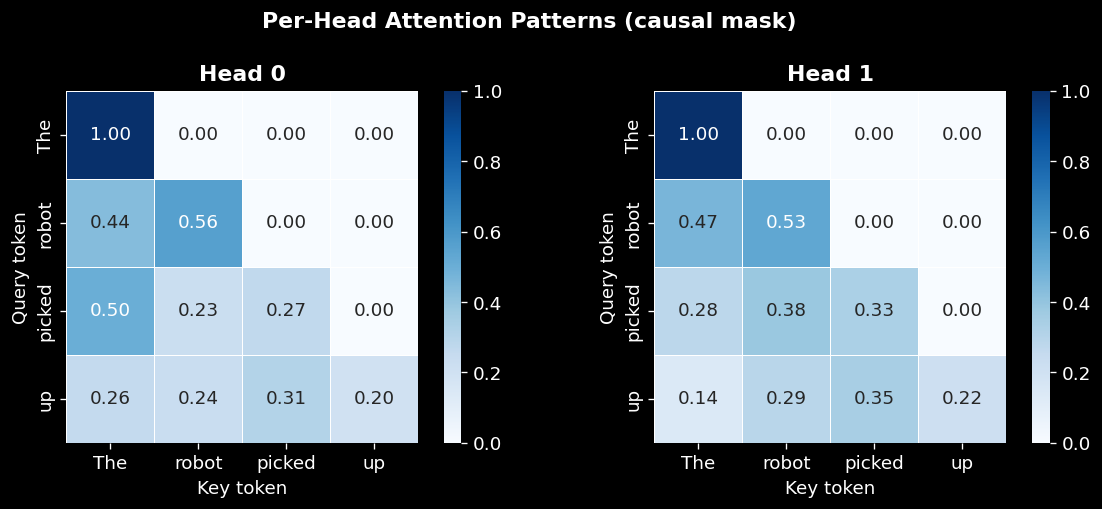

Different heads → different attention distributions over the same tokens.
After training, heads typically specialise into interpretable roles.


In [12]:
# ── Per-head attention heatmaps ───────────────────────────────────────────────
attn = mha.last_attn_weights[0]   # (n_heads, seq, seq)

fig, axes = plt.subplots(1, n_heads, figsize=(5 * n_heads, 4))
if n_heads == 1:
    axes = [axes]

for h, ax in enumerate(axes):
    sns.heatmap(attn[h].numpy(), annot=True, fmt='.2f',
                cmap='Blues', vmin=0, vmax=1,
                xticklabels=tokens, yticklabels=tokens,
                linewidths=0.4, linecolor='white',
                square=True, ax=ax)
    ax.set_title(f'Head {h}', fontweight='bold')
    ax.set_xlabel('Key token')
    ax.set_ylabel('Query token')

plt.suptitle('Per-Head Attention Patterns (causal mask)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Different heads → different attention distributions over the same tokens.')
print('After training, heads typically specialise into interpretable roles.')


<a id='5'></a>
## 5 — Key takeaways

| Concept | Details |
|---------|---------|
| **Why multi-head?** | Each head learns a different relationship pattern |
| **Split** | `d_model` ÷ `n_heads` = `d_k` per head; reshape, no copy |
| **Parallel attention** | All heads run simultaneously via batched matmul |
| **Concat + W_o** | Heads are recombined and mixed by the output projection |
| **Same param count** | Multi-head doesn't add parameters vs single-head |

**Next:** Notebook 04 wraps attention inside a full transformer block with FFN,
LayerNorm, and residual connections.
